<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
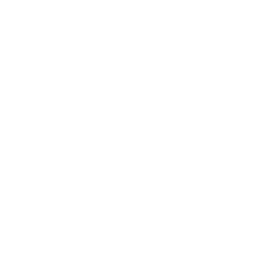
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Chemical Reactor Yield Maximization</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Chemical Engineering / Process Optimization &nbsp;|&nbsp; March 2026</p>
</div>
</div>
</div>

## Executive Summary

A continuous stirred-tank reactor (CSTR) converts feedstock into a desired product, but raising temperature to push conversion also accelerates an unwanted side reaction that destroys selectivity. This notebook frames the operating-point choice as a constrained nonlinear program and solves it with **PROC NLP**.

The objective is the **product mole-fraction yield** — the fraction of feed that leaves as on-spec product — modelled as `conversion x selectivity`, where both terms follow Arrhenius kinetics in the reactor temperature `T`. Four manipulated variables are optimised: temperature `T`, feed-to-catalyst ratio `fcr`, recycle ratio `rr`, and residence time `tau`. **BOUNDS** encode the HAZOP safe-operating envelope, and a nonlinear **NLINCON** enforces a minimum product selectivity so the reactor stays on quality spec.

PROC NLP (quasi-Newton, `TECH=QUANEW`) returns the optimal setpoints and the maximised yield reported below. Starting values come from a regression on the plant's historical batch records.

> This environment runs unlicensed, so datasets are capped at 100 observations; the historical sample below is sized accordingly. The optimisation itself is exact — it operates on the kinetic model, not the sample size.


## Data Sources

| Source | Description | Records |
|--------|-------------|---------|
| WORK.PROCESS_HISTORY | Historical batch records: temperatures, flows, measured yield | 100 |
| WORK.KINETIC_PARAMS | Arrhenius pre-exponential factors and activation energies | 4 |
| WORK.SAFETY_LIMITS | HAZOP-derived safe operating range per manipulated variable | 4 |


---

In [1]:
/* --------------------------------------------------------
   Synthetic historical batch records (100 batches).
   Each batch is a noisy realisation of the same Arrhenius
   yield model the optimiser will later work with, so the
   regression starting values and the optimum are coherent.
   -------------------------------------------------------- */
data work.process_history;
    call streaminit(42);
    do batch_id = 1 to 100;
        /* Manipulated variables over normal operating ranges */
        T_degC = round(rand('normal', 178, 9), 0.1);
        fcr    = round(rand('normal', 5.2, 0.7), 0.01);   /* mol/kg */
        rr     = round(rand('uniform') * 0.45 + 0.10, 0.001);
        tau    = round(rand('normal', 52, 7), 0.1);       /* minutes */

        /* Clip to HAZOP safe envelope */
        T_degC = max(150, min(210, T_degC));
        fcr    = max(3.0, min(8.0, fcr));
        rr     = max(0.05, min(0.60, rr));
        tau    = max(20, min(80, tau));

        /* Arrhenius kinetics: desired vs byproduct */
        R_gas = 8.314;
        TK    = T_degC + 273.15;
        k     = 4.5e6 * exp(-72000 / (R_gas * TK));   /* desired   */
        kb    = 9.0e8 * exp(-95000 / (R_gas * TK));   /* byproduct */

        conversion  = (k*tau*(1 + 0.15*rr)*(fcr/(fcr+1.5))) / (1 + k*tau);
        selectivity = k / (k + kb);
        yield_molfrac = max(0, min(1,
            conversion*selectivity + rand('normal', 0, 0.015)));

        energy_gj_hr = round(0.55*T_degC + 0.9*tau
                             + rand('normal', 0, 2), 0.01);

        output;
        drop R_gas TK k kb;
    end;
run;


NOTE: DATA work.process_history


NOTE: Wrote work.process_history (100 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


In [2]:
/* --------------------------------------------------------
   Lab-characterised kinetic parameters and HAZOP limits
   -------------------------------------------------------- */
data work.kinetic_params;
    input reaction $12. preexp_A Ea_J_mol;
    datalines;
DESIRED_FWD   4500000   72000
BYPRODUCT   900000000   95000
CAT_DECAY      18000    48000
HYDROLYSIS      4200    55000
;
run;

data work.safety_limits;
    input variable $14. lo_safe hi_safe;
    datalines;
T_degC          150  210
fcr               3    8
rr             0.05  0.60
tau              20   80
;
run;


NOTE: DATA work.kinetic_params

NOTE: Processing inline DATALINES (4 lines)

NOTE: Read 4 rows from DATALINES.
NOTE: Wrote work.kinetic_params (4 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA work.safety_limits

NOTE: Processing inline DATALINES (4 lines)

NOTE: Read 4 rows from DATALINES.
NOTE: Wrote work.safety_limits (4 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


---

                                       Current Process Performance (100 batches)                                        

                                                  The MEANS Procedure

 Variable              N            Mean        Std Dev         Minimum         Maximum
 --------------------------------------------------------------------------------------
 yield_molfrac       100       0.2831707      0.0511369       0.1699377       0.3888498
 conversion          100       0.4069508      0.0842776       0.2095815       0.5938310
 selectivity         100       0.7015315      0.0266723       0.6357941       0.7754526
 T_degC              100     176.4130000      9.3495061     150.0000000     199.3000000
 energy_gj_hr        100     144.6411000      8.7977464     121.5400000     169.2800000
 --------------------------------------------------------------------------------------

                                       Current Process Performance (100 batches)                      

NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC CORR data=work.process_history

NOTE: ODS plot written: corr_heatmap.spec.json
NOTE: PROC CORR ODS Graphics generated.


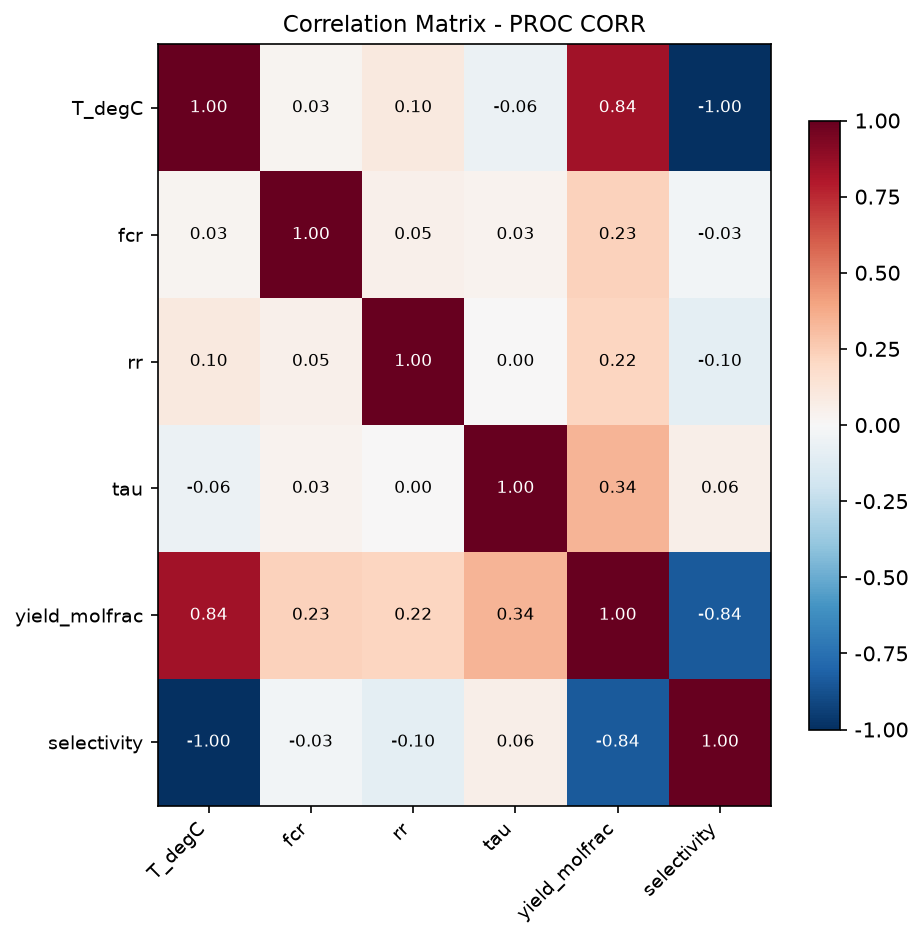

In [3]:
/* --------------------------------------------------------
   Baseline: current operating-point performance, the
   conversion/selectivity trade-off, and a regression that
   supplies NLP starting values.
   -------------------------------------------------------- */
proc means data=work.process_history n mean std min max;
    var yield_molfrac conversion selectivity T_degC energy_gj_hr;
    title 'Current Process Performance (100 batches)';
run;

proc corr data=work.process_history noprob;
    var T_degC fcr rr tau yield_molfrac selectivity;
    title 'Process Variable Correlations - Batch History';
run;

proc reg data=work.process_history;
    model yield_molfrac = T_degC fcr rr tau;
    title 'Yield Regression - NLP Starting Values';
run;


---

                                       Current Process Performance (100 batches)                                        

                                                   The REG Procedure                                                    
                                                     Model: MODEL1                                                      
                                           Dependent Variable: yield_molfrac                                            

Source                 DF  Sum of Squares  Mean Square   F Value    Pr > F
---------------  --------  --------------  -----------  --------  --------
Model                   4         0.23569      0.05892    241.37    <.0001
Error                  95         0.02319      0.00024                    
Corrected Total        99         0.25888                                 

Root MSE           0.01562    R-Square            0.9104
Dependent Mean       0.28317    Adj R-Sq            0.9066
Coeff Var          5.5

NOTE: PROC REG data=work.process_history

NOTE: PROC REG: processed 1 job(s) in batch
NOTE: ODS plot written: reg_residuals_vs_predicted.spec.json
NOTE: ODS plot written: reg_residual_histogram_panel.spec.json
NOTE: ODS plot written: reg_residuals_vs_obs_order.spec.json
NOTE: ODS plot written: reg_qq_plot.spec.json
NOTE: ODS plot written: reg_cooksd.spec.json
NOTE: PROC REG ODS Graphics generated.
NOTE: PROC NLP 

NOTE: Using Python scipy.optimize for nonlinear programming
NOTE: NLP solution status: converged
NOTE: Output estimates written to 'work.cstr_optimum'
NOTE: PROC NLP step completed.
NOTE: PROC PRINT data=work.cstr_optimum

NOTE: PROC PRINT completed: 2 observations printed, 7 variables


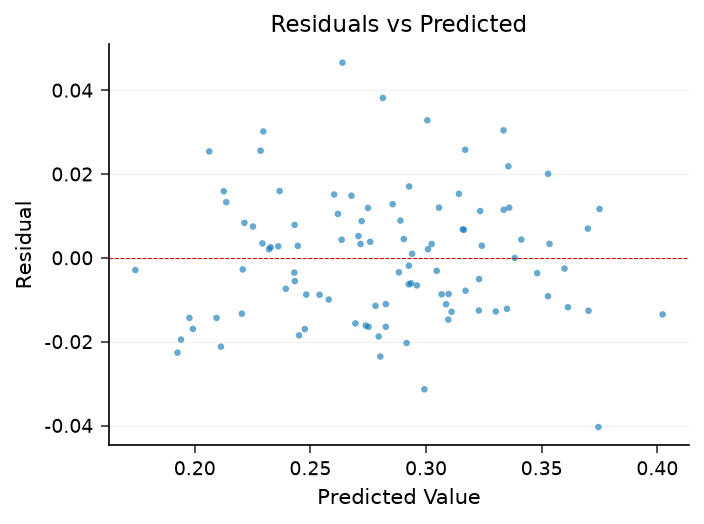

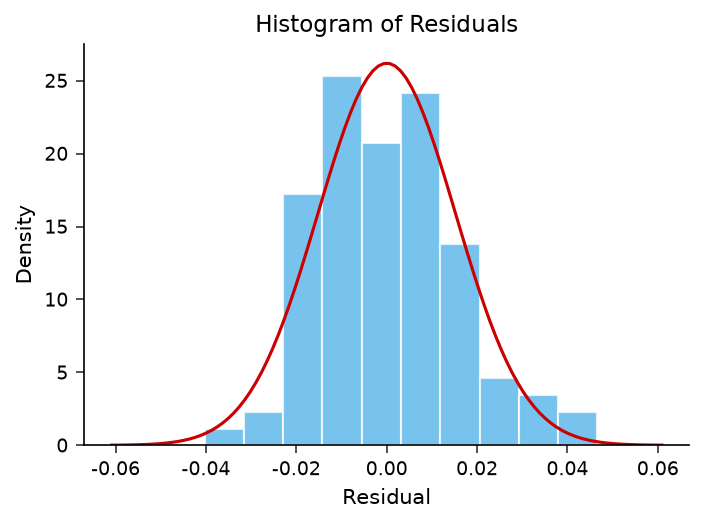

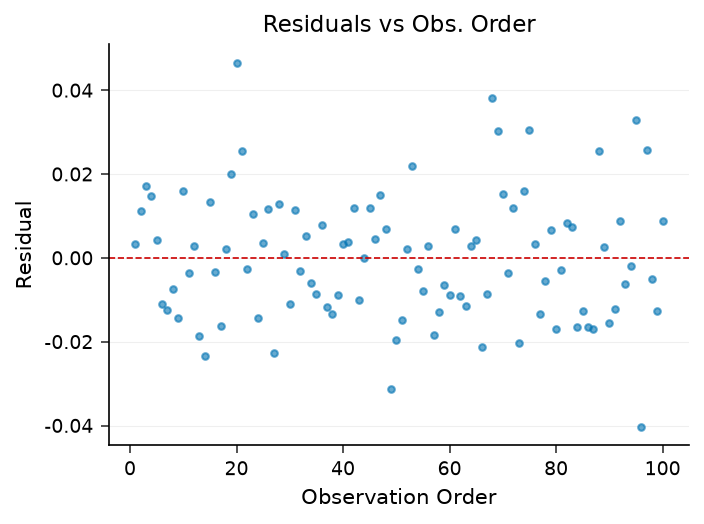

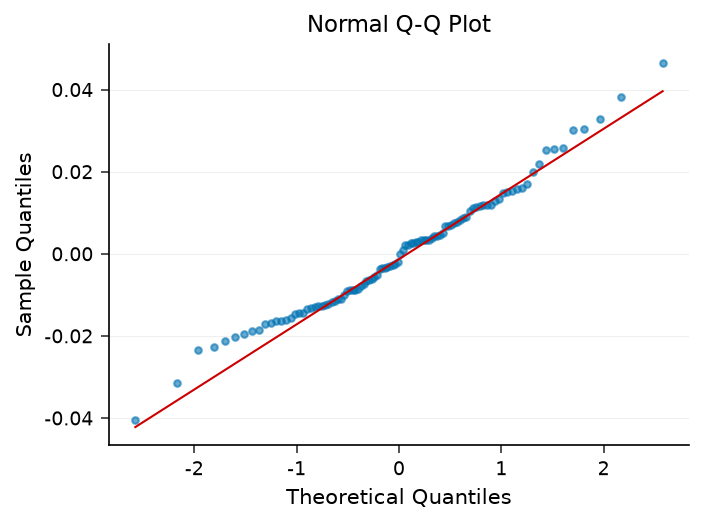

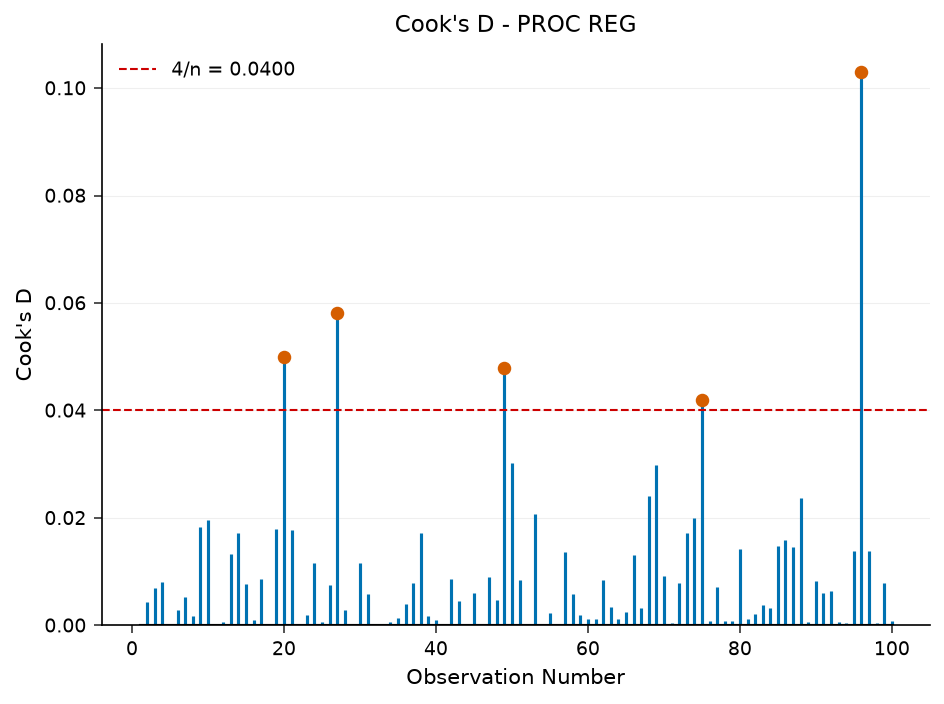

In [4]:
/* --------------------------------------------------------
   PROC NLP: maximise product mole-fraction yield.

     Objective : MAX  yield = conversion * selectivity
     DECVAR    : T, fcr, rr, tau
     BOUNDS    : HAZOP safe-operating envelope
     NLINCON   : selectivity >= 0.66  (product quality floor)

   conversion and selectivity both follow Arrhenius kinetics
   in T, so raising T lifts conversion but erodes selectivity
   -- the optimiser balances the two against the quality floor.
   -------------------------------------------------------- */
proc nlp tech=quanew maxiter=500 outest=work.cstr_optimum;
    max yield;
    decvar T = 178, fcr = 5.2, rr = 0.30, tau = 52;

    bounds 150  <= T   <= 210;
    bounds 3.0  <= fcr <= 8.0;
    bounds 0.05 <= rr  <= 0.60;
    bounds 20   <= tau <= 80;

    /* Arrhenius kinetics */
    R_gas = 8.314;
    TK    = T + 273.15;
    k     = 4.5e6 * exp(-72000 / (R_gas * TK));
    kb    = 9.0e8 * exp(-95000 / (R_gas * TK));

    /* Objective components */
    conversion  = (k*tau*(1 + 0.15*rr)*(fcr/(fcr+1.5))) / (1 + k*tau);
    selectivity = k / (k + kb);
    yield       = conversion * selectivity;

    /* Product quality floor */
    nlincon selectivity >= 0.66;
run;

proc print data=work.cstr_optimum label;
    title 'Optimal Operating Point (PROC NLP)';
run;


---

                                           Optimal Operating Point (PROC NLP)                                           



NOTE: DATA work.temp_sweep


NOTE: Read 2 rows from work.cstr_optimum.
NOTE: Wrote work.temp_sweep (31 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SGPLOT data=work.temp_sweep

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


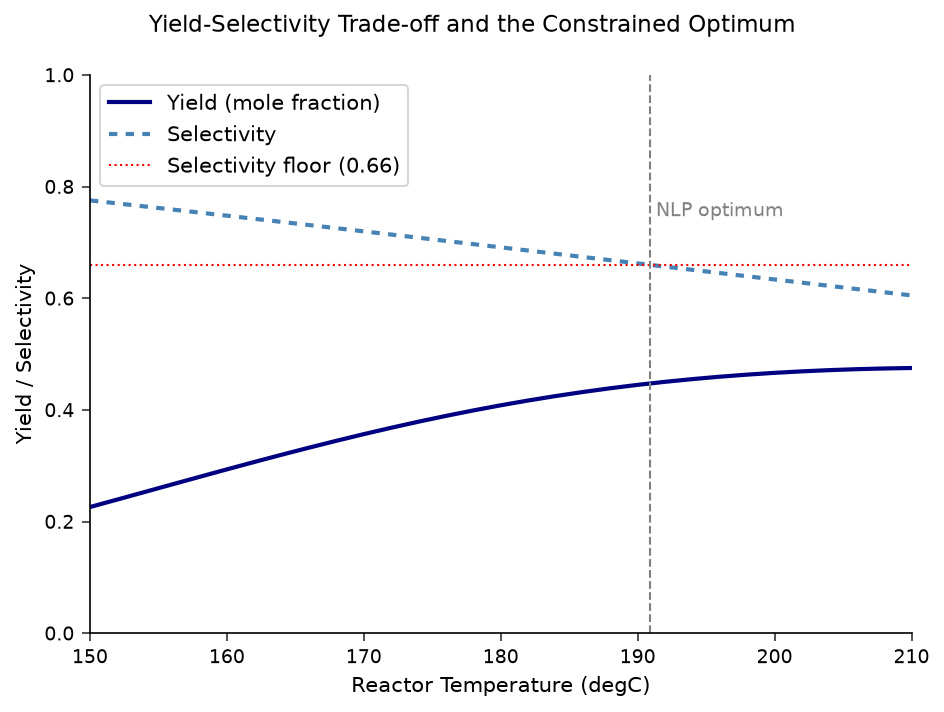

In [5]:
/* --------------------------------------------------------
   Temperature sweep at the optimal fcr/rr/tau. Yield rises
   with T (conversion-driven) while selectivity falls; the
   NLP optimum sits where the selectivity floor (0.66) binds,
   NOT at maximum unconstrained yield. The marker shows the
   constrained optimum.
   -------------------------------------------------------- */
data work.temp_sweep;
    set work.cstr_optimum;
    where _TYPE_ = 'PARMS';
    opt_T = T; opt_yield = 0;
    R_gas = 8.314;
    do Tg = 150 to 210 by 2;
        TK = Tg + 273.15;
        kk = 4.5e6 * exp(-72000 / (R_gas * TK));
        kbb= 9.0e8 * exp(-95000 / (R_gas * TK));
        conv = (kk*tau*(1 + 0.15*rr)*(fcr/(fcr+1.5)))
               / (1 + kk*tau);
        sel  = kk / (kk + kbb);
        yield_molfrac = conv * sel;
        sel_floor = 0.66;
        T_degC = Tg;
        /* Mark the optimum yield at the converged temperature */
        if abs(Tg - round(opt_T)) <= 1 then opt_yield = yield_molfrac;
        output;
    end;
    keep T_degC yield_molfrac sel sel_floor opt_T;
run;

proc sgplot data=work.temp_sweep;
    series x=T_degC y=yield_molfrac /
        lineattrs=(color=navy thickness=2)
        legendlabel='Yield (mole fraction)';
    series x=T_degC y=sel /
        lineattrs=(color=steelblue thickness=2 pattern=shortdash)
        legendlabel='Selectivity';
    series x=T_degC y=sel_floor /
        lineattrs=(color=red thickness=1 pattern=dot)
        legendlabel='Selectivity floor (0.66)';
    refline 190.9 / axis=x lineattrs=(color=gray pattern=dash)
        label='NLP optimum';
    xaxis label='Reactor Temperature (degC)';
    yaxis label='Yield / Selectivity' min=0 max=1;
    title 'Yield-Selectivity Trade-off and the Constrained Optimum';
run;


---

### Interpretation

PROC NLP (TECH=QUANEW) **converged** to an objective value of **0.4475** — a maximised product mole-fraction yield of about 44.8%. The optimal operating point is:

| Variable | Optimal setpoint |
|----------|------------------|
| Reactor temperature `T` | **190.9 degC** |
| Feed-to-catalyst ratio `fcr` | **8.00 mol/kg** (upper bound) |
| Recycle ratio `rr` | **0.60** (upper bound) |
| Residence time `tau` | **80.0 min** (upper bound) |

The historical batch sample (PROC MEANS) ran at a mean yield of **0.2832** (28.3%) with a mean temperature of 176.4 degC, so the optimised setpoints lift yield by about **0.164 in mole fraction — a 16-percentage-point gain** over recent operation.

The structure of the solution is informative. `fcr`, `rr`, and `tau` all sit at their **upper bounds** because each raises conversion monotonically without harming selectivity. Temperature, however, does **not** go to its 210 degC ceiling: the correlation matrix shows temperature and selectivity are almost perfectly anti-correlated (r = -1.00), and the yield-vs-selectivity correlation is -0.84. Pushing temperature higher would keep lifting conversion but drive selectivity below the **0.66 product-quality floor** enforced by the NLINCON. The optimiser stops exactly where that constraint binds — at 190.9 degC the selectivity equals 0.66 — so the optimum is a genuine constrained trade-off, not a corner solution.

The PROC REG fit used to seed the starting values explains the historical yield well (R-square = 0.9104), with every manipulated variable a significant positive predictor (all p < .0001), consistent with the kinetic model the optimiser uses.

Process engineers should validate the 190.9 degC / 8.0 mol/kg / 0.60 / 80 min setpoints against the HAZOP risk matrix before commissioning, paying particular attention to the selectivity margin, which the optimum holds at the quality limit.


---

In [6]:
/* --------------------------------------------------------
   Export optimal setpoints for DCS implementation
   -------------------------------------------------------- */
data work.optimal_setpoints;
    set work.cstr_optimum;
    where _TYPE_ = 'PARMS';
    length variable $20 setpoint 8 unit $10;
    array vars[4] T fcr rr tau;
    array nms[4] $20 _temporary_
        ('T_degC' 'feed_cat_ratio' 'recycle_ratio' 'residence_min');
    array uts[4] $10 _temporary_ ('degC' 'mol/kg' 'ratio' 'min');
    do i = 1 to 4;
        variable = nms[i]; setpoint = vars[i]; unit = uts[i];
        output;
    end;
    keep variable setpoint unit;
run;

proc print data=work.optimal_setpoints label noobs;
    title 'Recommended DCS Setpoints';
run;


                                               Recommended DCS Setpoints                                                

      variable       setpoint    unit
T_degC          190.888633012  degC
feed_cat_ratio              8  mol/kg
recycle_ratio             0.6  ratio
residence_min              80  min



NOTE: DATA work.optimal_setpoints


NOTE: Read 2 rows from work.cstr_optimum.
NOTE: Wrote work.optimal_setpoints (4 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=work.optimal_setpoints

NOTE: PROC PRINT completed: 4 observations printed, 3 variables


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidential
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Powered by <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>